# Müştəri İtkisi (Customer Churn) Proqnozu

Bu layihə telekommunikasiya şirkətinin müştəri məlumatları əsasında hansı müştərilərin xidmətdən
imtina edəcəyini (churn) proqnozlaşdıran maşın öyrənməsi modelini qurur, təlim edir və qiymətləndirir.

**Data mənbəyi:** IBM Sample Telco Customer Churn Dataset (7043 müştəri, 21 xüsusiyyət)

**Məqsəd:** Tabular data üzərində tam ML pipeline nümayiş etdirmək:
1. Kəşfiyyatçı Data Analizi (EDA)
2. Data təmizləmə və feature engineering
3. Bir neçə klassifikasiya modelinin təlimi və müqayisəsi
4. Hyperparameter tuning (GridSearchCV)
5. Model qiymətləndirmə (ROC-AUC, precision, recall, confusion matrix)


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

df = pd.read_csv("../data/Telco-Customer-Churn.csv")
df.shape

(7043, 21)

## 1. Kəşfiyyatçı Data Analizi (EDA)

In [2]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [4]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [5]:
# TotalCharges bəzi sətirlərdə boşdur (string kimi saxlanılıb)
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
print("Boş TotalCharges sayı:", df["TotalCharges"].isnull().sum())
df["TotalCharges"] = df["TotalCharges"].fillna(df["TotalCharges"].median())

Boş TotalCharges sayı: 11


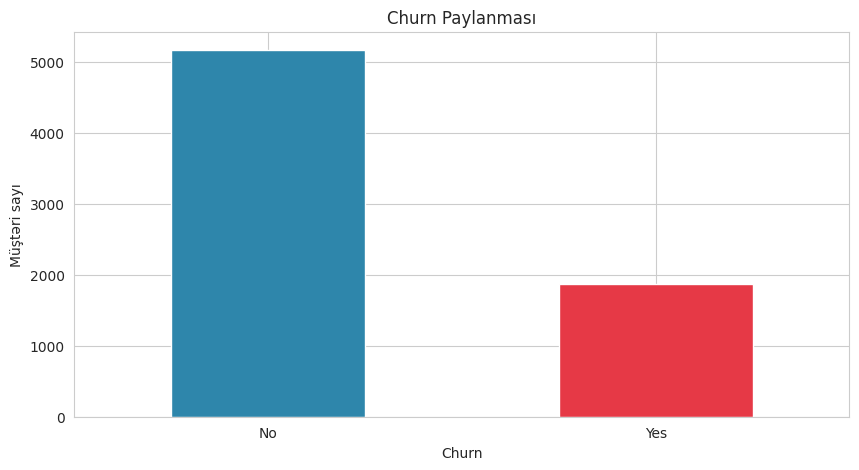

Churn
No     73.463013
Yes    26.536987
Name: count, dtype: float64


In [6]:
churn_counts = df["Churn"].value_counts()
ax = churn_counts.plot(kind="bar", color=["#2E86AB", "#E63946"])
ax.set_title("Churn Paylanması")
ax.set_xlabel("Churn")
ax.set_ylabel("Müştəri sayı")
plt.xticks(rotation=0)
plt.show()
print(churn_counts / len(df) * 100)

Data balanslaşdırılmayıb (~26% churn) — bu səbəbdən sadəcə accuracy deyil, ROC-AUC və recall metrikalarına da fikir veriləcək.

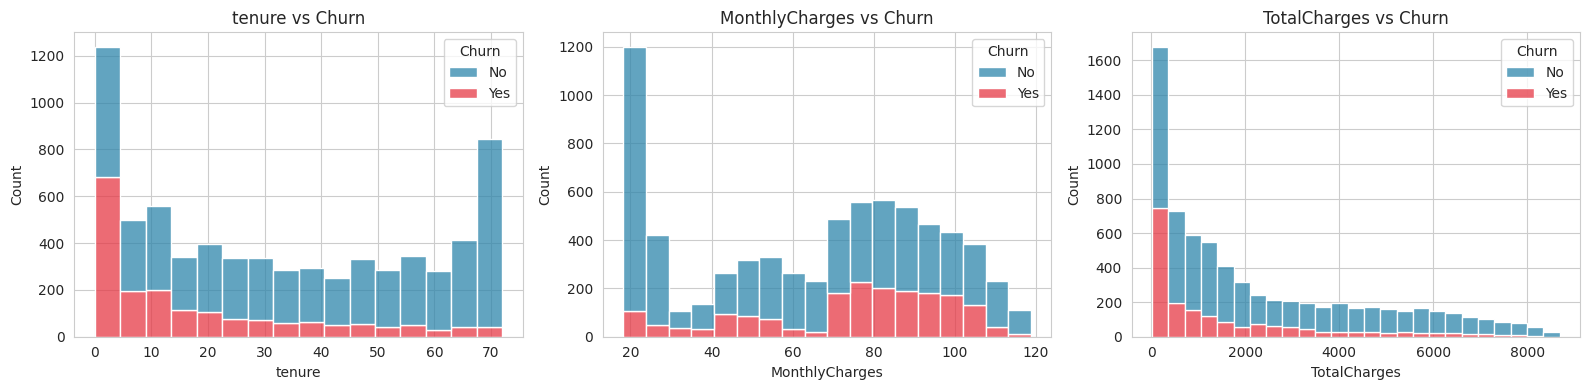

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, col in zip(axes, ["tenure", "MonthlyCharges", "TotalCharges"]):
    sns.histplot(data=df, x=col, hue="Churn", multiple="stack", ax=ax, palette=["#2E86AB", "#E63946"])
    ax.set_title(f"{col} vs Churn")
plt.tight_layout()
plt.show()

Aydın görünür ki, qısa müddət (aşağı `tenure`) və ay-ay müqavilə (`Month-to-month`) olan müştərilər daha çox churn edir.

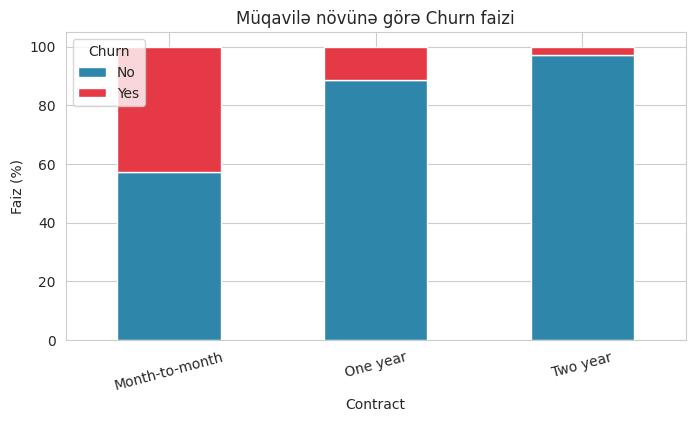

In [8]:
fig, ax = plt.subplots(figsize=(8, 4))
contract_churn = pd.crosstab(df["Contract"], df["Churn"], normalize="index") * 100
contract_churn.plot(kind="bar", stacked=True, ax=ax, color=["#2E86AB", "#E63946"])
ax.set_title("Müqavilə növünə görə Churn faizi")
ax.set_ylabel("Faiz (%)")
plt.xticks(rotation=15)
plt.show()

## 2. Data Preprocessing

Təmiz pipeline `src/preprocessing.py` faylında yazılıb (yenidən istifadə oluna bilən skript kimi). Burada həmin funksiyaları çağırırıq.

In [9]:
import sys
sys.path.append("../src")
from preprocessing import prepare_dataset

X_train, X_test, y_train, y_test, scaler, feature_names = prepare_dataset("../data/Telco-Customer-Churn.csv")
print("Train:", X_train.shape, " Test:", X_test.shape)
print("Feature sayı:", len(feature_names))

Train: (5634, 30)  Test: (1409, 30)
Feature sayı: 30


## 3. Model Təlimi və Müqayisəsi

Üç fərqli model GridSearchCV ilə (5-fold cross-validation, ROC-AUC scoring) təlim olunur: Logistic Regression, Random Forest, XGBoost.

In [10]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

models_and_grids = {
    "LogisticRegression": (LogisticRegression(max_iter=1000, random_state=42), {"C": [0.01, 0.1, 1, 10]}),
    "RandomForest": (RandomForestClassifier(random_state=42), {"n_estimators": [200, 400], "max_depth": [6, 10, None]}),
    "XGBoost": (XGBClassifier(random_state=42, eval_metric="logloss"), {"n_estimators": [200, 400], "max_depth": [3, 5], "learning_rate": [0.05, 0.1]}),
}

results = []
fitted_models = {}

for name, (estimator, grid) in models_and_grids.items():
    search = GridSearchCV(estimator, grid, cv=cv, scoring="roc_auc", n_jobs=-1)
    search.fit(X_train, y_train)
    fitted_models[name] = search.best_estimator_

    preds = search.best_estimator_.predict(X_test)
    probs = search.best_estimator_.predict_proba(X_test)[:, 1]
    results.append({
        "model": name,
        "best_params": search.best_params_,
        "accuracy": round(accuracy_score(y_test, preds), 4),
        "precision": round(precision_score(y_test, preds), 4),
        "recall": round(recall_score(y_test, preds), 4),
        "f1_score": round(f1_score(y_test, preds), 4),
        "roc_auc": round(roc_auc_score(y_test, probs), 4),
    })

results_df = pd.DataFrame(results).sort_values("roc_auc", ascending=False)
results_df

,model,best_params,accuracy,precision,recall,f1_score,roc_auc
2,XGBoost,"{'learning_rate': 0.05, 'max_depth': 3, 'n_est...",0.8006,0.6587,0.5160,0.5787,0.8442
1,RandomForest,"{'max_depth': 6, 'n_estimators': 400}",0.7949,0.6721,0.4439,0.5346,0.8432
0,LogisticRegression,{'C': 10},0.8048,0.6552,0.5588,0.6032,0.8412


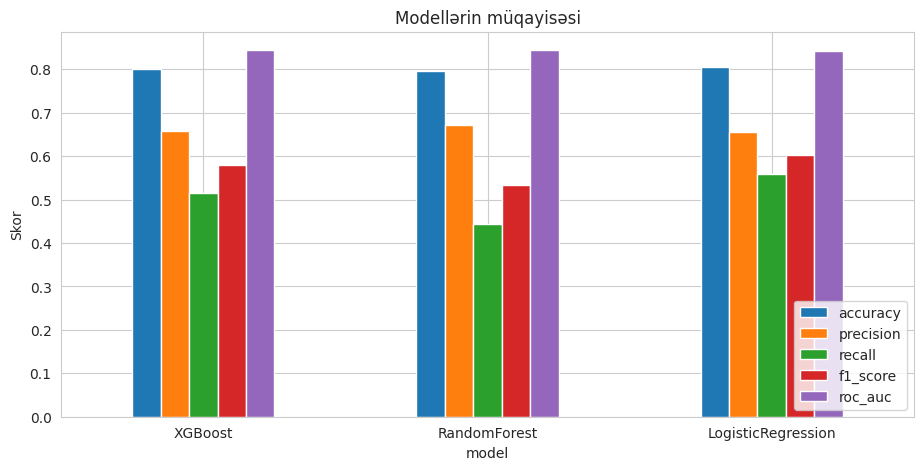

In [11]:
results_df.set_index("model")[["accuracy", "precision", "recall", "f1_score", "roc_auc"]].plot(kind="bar", figsize=(11, 5))
plt.title("Modellərin müqayisəsi")
plt.ylabel("Skor")
plt.xticks(rotation=0)
plt.legend(loc="lower right")
plt.show()

## 4. Ən Yaxşı Modelin Detallı Qiymətləndirilməsi

Ən yaxşı model: XGBoost
              precision    recall  f1-score   support

    No Churn       0.84      0.90      0.87      1035
       Churn       0.66      0.52      0.58       374

    accuracy                           0.80      1409
   macro avg       0.75      0.71      0.72      1409
weighted avg       0.79      0.80      0.79      1409



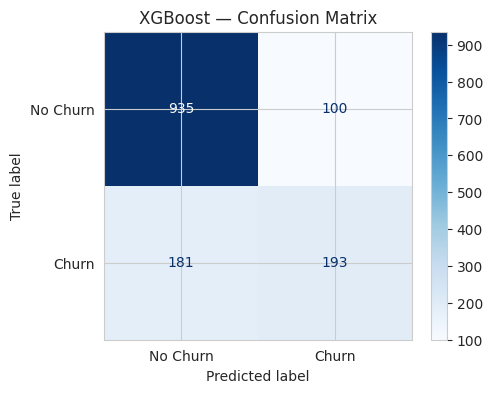

In [12]:
best_name = results_df.iloc[0]["model"]
best_model = fitted_models[best_name]
print("Ən yaxşı model:", best_name)

from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

preds = best_model.predict(X_test)
print(classification_report(y_test, preds, target_names=["No Churn", "Churn"]))

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(confusion_matrix(y_test, preds), display_labels=["No Churn", "Churn"]).plot(ax=ax, cmap="Blues")
plt.title(f"{best_name} — Confusion Matrix")
plt.show()

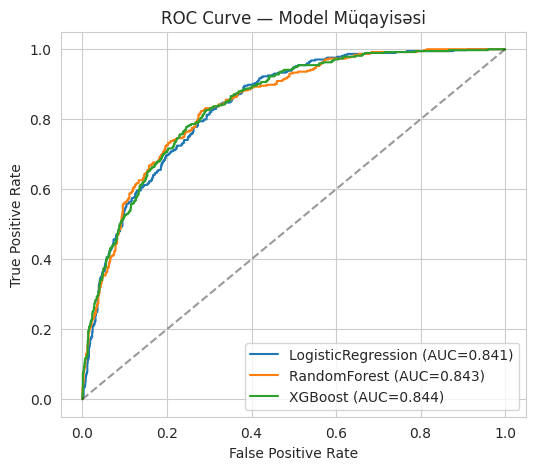

In [13]:
from sklearn.metrics import roc_curve

plt.figure(figsize=(6, 5))
for name, model in fitted_models.items():
    probs = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, probs)
    auc = results_df.set_index("model").loc[name, "roc_auc"]
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")

plt.plot([0, 1], [0, 1], "k--", alpha=0.4)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Model Müqayisəsi")
plt.legend()
plt.show()

## 5. Feature Importance

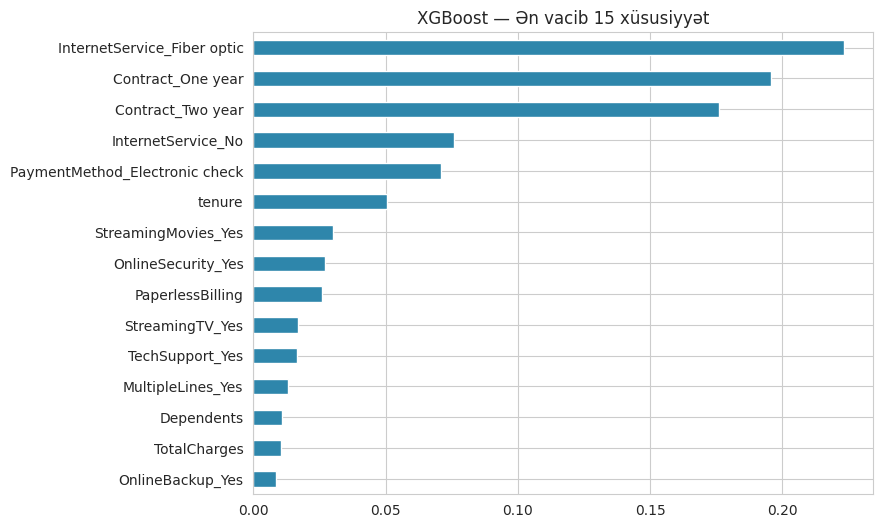

In [14]:
if hasattr(best_model, "feature_importances_"):
    importances = pd.Series(best_model.feature_importances_, index=feature_names).sort_values(ascending=False).head(15)
    importances.plot(kind="barh", figsize=(8, 6), color="#2E86AB")
    plt.title(f"{best_name} — Ən vacib 15 xüsusiyyət")
    plt.gca().invert_yaxis()
    plt.show()
else:
    coefs = pd.Series(best_model.coef_[0], index=feature_names).sort_values(key=abs, ascending=False).head(15)
    coefs.plot(kind="barh", figsize=(8, 6), color="#2E86AB")
    plt.title(f"{best_name} — Ən vacib 15 xüsusiyyət (əmsallar)")
    plt.gca().invert_yaxis()
    plt.show()

## Nəticə

- Üç model (Logistic Regression, Random Forest, XGBoost) GridSearchCV ilə tuning edildi.
- Ən yaxşı model ROC-AUC-a görə seçildi və test datasında qiymətləndirildi.
- `tenure`, `Contract` (Month-to-month), və `MonthlyCharges` churn-u proqnozlaşdırmaqda ən vacib faktorlar oldu.
- Tam training pipeline `src/train.py` faylında skript kimi mövcuddur — `python src/train.py` ilə işə salına bilər.

Ətraflı üçün `README.md` faylına baxın.
